# Notebook 05: 三种势垒横向对比

## 方势垒 vs Eckart势 vs 双势垒

---

In [1]:
import sys
sys.path.insert(0, '.')

import numpy as np
import matplotlib.pyplot as plt
from config import SimParams
from potentials import get_potential
from propagator import propagate
from observables import eckart_analytical_T_simple
from visualization import (
    set_style, plot_three_barriers_comparison,
    plot_snapshots, plot_TR_evolution, plot_momentum_spectrum
)

set_style()

## 1. 统一参数运行三种势垒

使用相同入射波包，对比三种势垒的透射/反射行为

In [2]:
p_common = SimParams(
    V0=10.0,
    k0=5.0,
    sigma=3.0,
    x0=-20.0,
    dt=0.005,
    N_t=4000,
    barrier_a=-1.0, barrier_b=1.0,
    alpha=1.0, x_c=0.0,
    b1_a=-3.0, b1_b=-1.0,
    b2_a=1.0, b2_b=3.0,
)

print(f'公共参数: V0={p_common.V0}, k0={p_common.k0}, E={p_common.E_kinetic:.2f}')
print(f'E/V0 = {p_common.E_kinetic/p_common.V0:.3f}')

公共参数: V0=10.0, k0=5.0, E=12.50
E/V0 = 1.250


In [3]:
print('正在运行方势垒模拟...')
result_square = propagate(p_common, 'square')
print(f'  T = {result_square.T_values[-1]:.6f}, R = {result_square.R_values[-1]:.6f}')

print('正在运行 Eckart 势模拟...')
result_eckart = propagate(p_common, 'eckart')
print(f'  T = {result_eckart.T_values[-1]:.6f}, R = {result_eckart.R_values[-1]:.6f}')

print('正在运行双势垒模拟...')
result_double = propagate(p_common, 'double')
print(f'  T = {result_double.T_values[-1]:.6f}, R = {result_double.R_values[-1]:.6f}')

正在运行方势垒模拟...
  T = 0.664035, R = 0.335965
正在运行 Eckart 势模拟...
  T = 0.953549, R = 0.046451
正在运行双势垒模拟...
  T = 0.536818, R = 0.462080


## 2. 三种势垒形态对比

C:\Users\User1\AppData\Local\Temp\ipykernel_24732\3121021348.py:14: UserWarning: Glyph 19977 (\N{CJK UNIFIED IDEOGRAPH-4E09}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\User1\AppData\Local\Temp\ipykernel_24732\3121021348.py:14: UserWarning: Glyph 31181 (\N{CJK UNIFIED IDEOGRAPH-79CD}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\User1\AppData\Local\Temp\ipykernel_24732\3121021348.py:14: UserWarning: Glyph 21183 (\N{CJK UNIFIED IDEOGRAPH-52BF}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\User1\AppData\Local\Temp\ipykernel_24732\3121021348.py:14: UserWarning: Glyph 22418 (\N{CJK UNIFIED IDEOGRAPH-5792}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\User1\AppData\Local\Temp\ipykernel_24732\3121021348.py:14: UserWarning: Glyph 24418 (\N{CJK UNIFIED IDEOGRAPH-5F62}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\User1\AppData\Local\Temp\ipykernel_24732\3121021348.py:14: UserWarning: Glyph 24577 (\

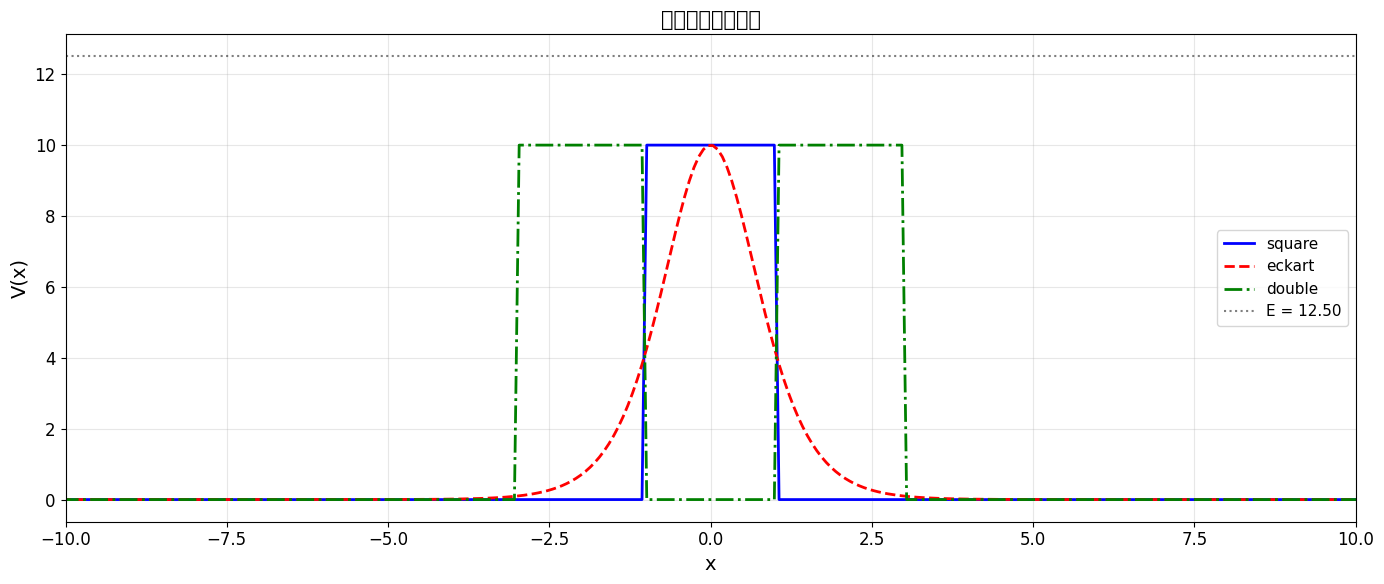

In [4]:
x = p_common.x
fig, ax = plt.subplots(figsize=(14, 6))

for name, color, ls in [('square', 'blue', '-'), ('eckart', 'red', '--'), ('double', 'green', '-.')]:
    V = np.real(get_potential(x, p_common, name, with_cap=False))
    ax.plot(x, V, color=color, linestyle=ls, linewidth=2, label=name)

ax.axhline(p_common.E_kinetic, color='k', linestyle=':', alpha=0.5, label=f'E = {p_common.E_kinetic:.2f}')
ax.set_xlabel('x')
ax.set_ylabel('V(x)')
ax.set_title('三种势垒形态对比')
ax.set_xlim(-10, 10)
ax.legend()
plt.tight_layout()
plt.show()

## 3. T/R 演化对比

C:\Users\User1\Desktop\OpenCodeProjects\quantum_barrier_sim\visualization.py:248: UserWarning: Glyph 36879 (\N{CJK UNIFIED IDEOGRAPH-900F}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\User1\Desktop\OpenCodeProjects\quantum_barrier_sim\visualization.py:248: UserWarning: Glyph 23556 (\N{CJK UNIFIED IDEOGRAPH-5C04}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\User1\Desktop\OpenCodeProjects\quantum_barrier_sim\visualization.py:248: UserWarning: Glyph 29575 (\N{CJK UNIFIED IDEOGRAPH-7387}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\User1\Desktop\OpenCodeProjects\quantum_barrier_sim\visualization.py:248: UserWarning: Glyph 21453 (\N{CJK UNIFIED IDEOGRAPH-53CD}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\User1\Desktop\OpenCodeProjects\quantum_barrier_sim\visualization.py:248: UserWarning: Glyph 27010 (\N{CJK UNIFIED IDEOGRAPH-6982}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\User1\Desktop\Op

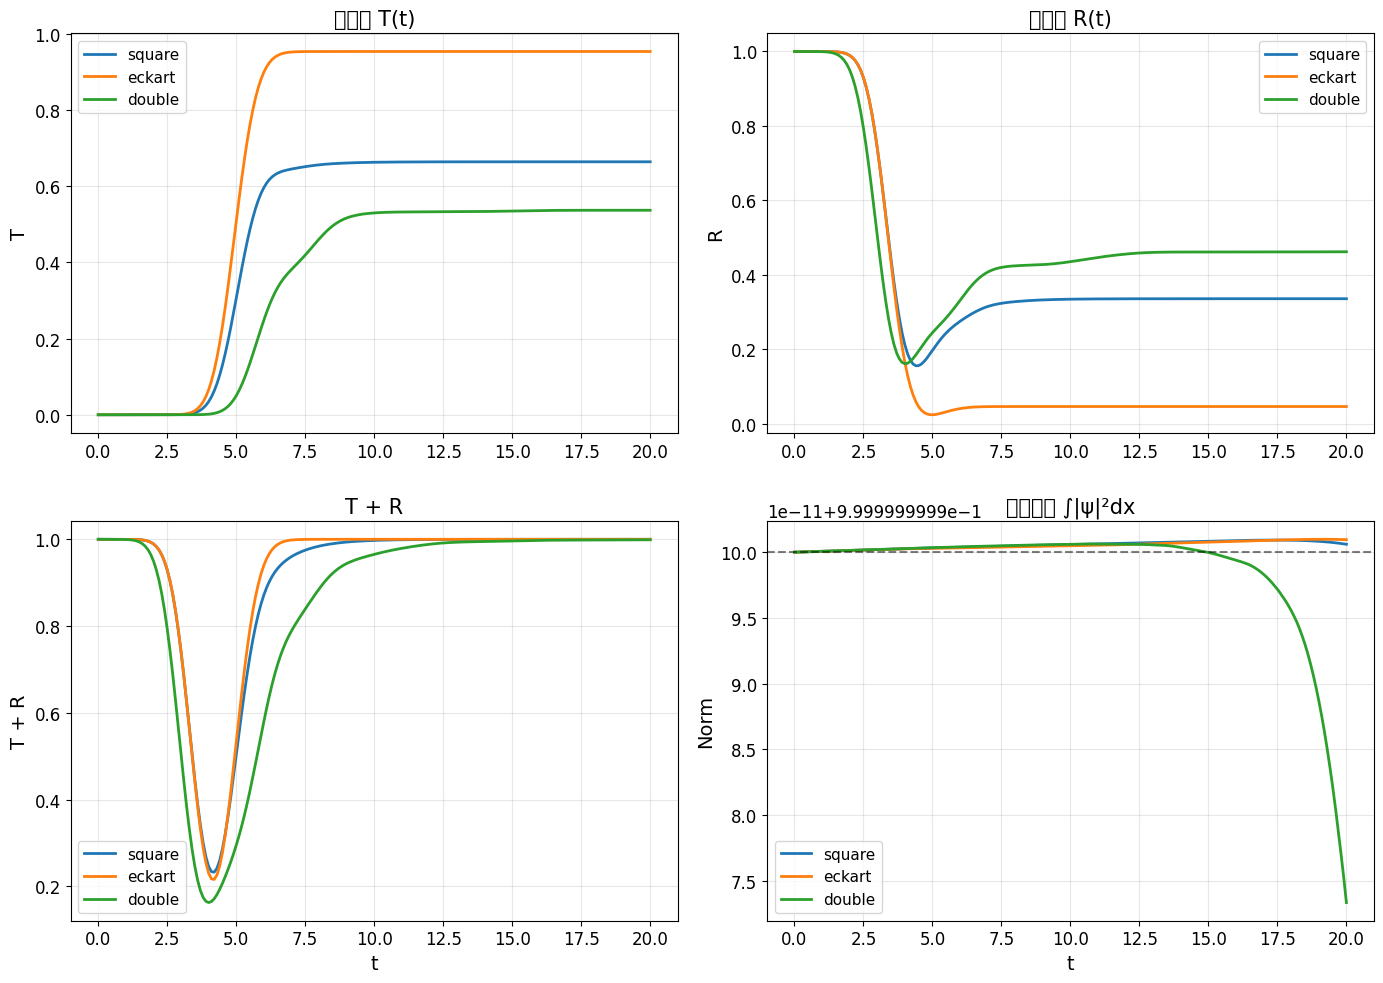

In [5]:
results = [result_square, result_eckart, result_double]
fig = plot_three_barriers_comparison(results)
plt.show()

## 4. 最终透射率汇总

In [6]:
names = ['Square', 'Eckart', 'Double']
results_list = [result_square, result_eckart, result_double]

print(f'{"Barrier":<12} {"T":<12} {"R":<12} {"T+R":<12} {"Norm":<12}')
print('-' * 60)
for name, res in zip(names, results_list):
    T = res.T_values[-1]
    R = res.R_values[-1]
    norm = res.norm_values[-1]
    print(f'{name:<12} {T:<12.6f} {R:<12.6f} {T+R:<12.6f} {norm:<12.8f}')

print(f'\nEckart 解析 T = {eckart_analytical_T_simple(np.array([p_common.E_kinetic]), p_common.V0, p_common.alpha)[0]:.6f}')

Barrier      T            R            T+R          Norm        
------------------------------------------------------------
Square       0.664035     0.335965     1.000000     1.00000000  
Eckart       0.953549     0.046451     1.000000     1.00000000  
Double       0.536818     0.462080     0.998898     1.00000000  

Eckart 解析 T = 0.970483


## 5. 快照对比 — 同一时刻

C:\Users\User1\AppData\Local\Temp\ipykernel_24732\1723480782.py:30: UserWarning: Glyph 19977 (\N{CJK UNIFIED IDEOGRAPH-4E09}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\User1\AppData\Local\Temp\ipykernel_24732\1723480782.py:30: UserWarning: Glyph 31181 (\N{CJK UNIFIED IDEOGRAPH-79CD}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\User1\AppData\Local\Temp\ipykernel_24732\1723480782.py:30: UserWarning: Glyph 21183 (\N{CJK UNIFIED IDEOGRAPH-52BF}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\User1\AppData\Local\Temp\ipykernel_24732\1723480782.py:30: UserWarning: Glyph 22418 (\N{CJK UNIFIED IDEOGRAPH-5792}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\User1\AppData\Local\Temp\ipykernel_24732\1723480782.py:30: UserWarning: Glyph 27874 (\N{CJK UNIFIED IDEOGRAPH-6CE2}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\User1\AppData\Local\Temp\ipykernel_24732\1723480782.py:30: UserWarning: Glyph 21253 (\

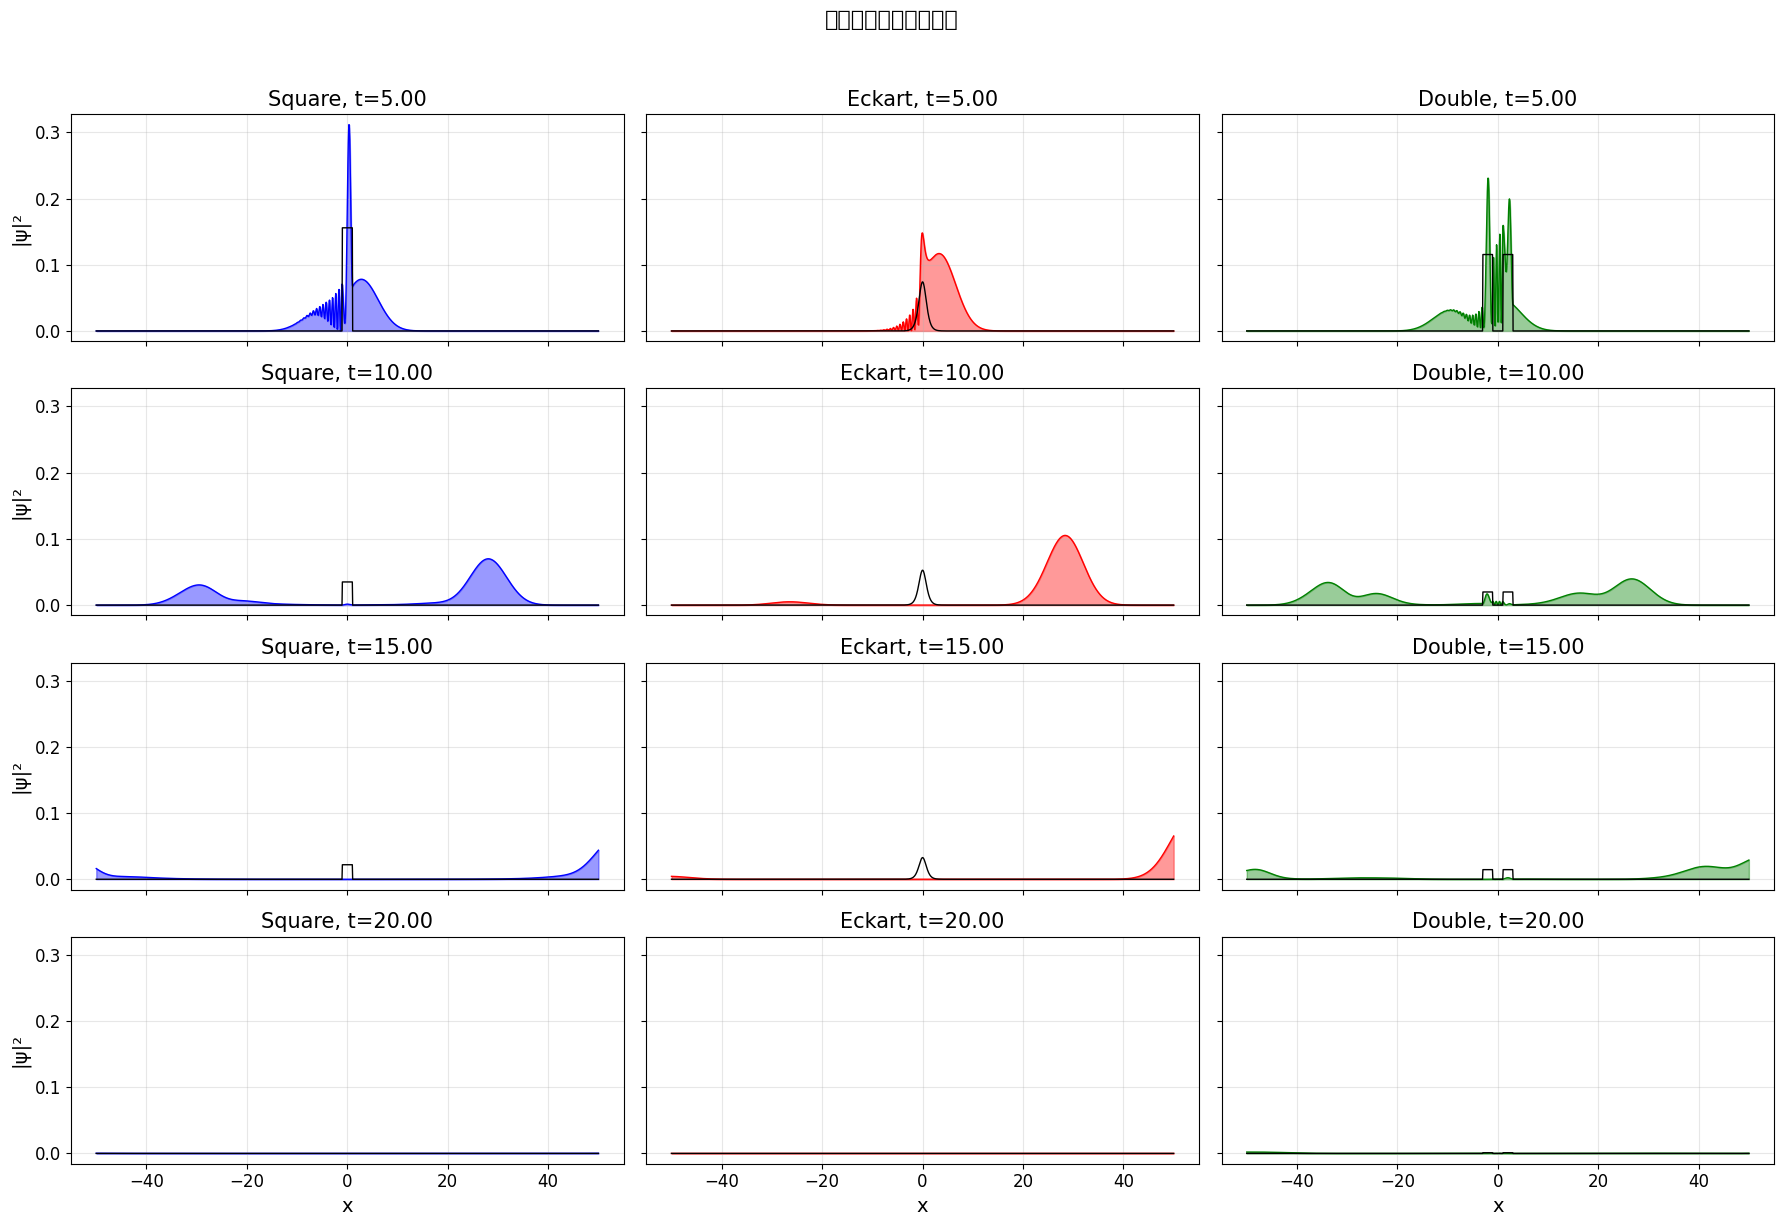

In [7]:
x = p_common.x
mask = (x >= -50) & (x <= 50)
x_plot = x[mask]

n_frames = len(result_square.prob_densities)
snap_indices = [n_frames//4, n_frames//2, 3*n_frames//4, n_frames-1]

fig, axes = plt.subplots(len(snap_indices), 3, figsize=(18, 3*len(snap_indices)), sharex=True, sharey=True)

for col, (name, res, color) in enumerate(zip(
    ['Square', 'Eckart', 'Double'],
    results_list,
    ['blue', 'red', 'green']
)):
    V = np.real(get_potential(x, p_common, name.lower(), with_cap=False))
    for row, idx in enumerate(snap_indices):
        ax = axes[row, col]
        rho = res.prob_densities[idx][mask]
        ax.fill_between(x_plot, 0, rho, alpha=0.4, color=color)
        ax.plot(x_plot, rho, color=color, linewidth=1)
        V_scaled = V[mask] / max(V.max(), 1) * rho.max() * 0.5
        ax.plot(x_plot, V_scaled, 'k-', linewidth=1)
        ax.set_title(f'{name}, t={res.times[idx]:.2f}')
        if col == 0:
            ax.set_ylabel('|ψ|²')
        if row == len(snap_indices) - 1:
            ax.set_xlabel('x')

plt.suptitle('三种势垒波包演化对比', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

## 6. 动量谱对比

C:\Users\User1\AppData\Local\Temp\ipykernel_24732\2887785718.py:22: UserWarning: Glyph 26368 (\N{CJK UNIFIED IDEOGRAPH-6700}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\User1\AppData\Local\Temp\ipykernel_24732\2887785718.py:22: UserWarning: Glyph 32456 (\N{CJK UNIFIED IDEOGRAPH-7EC8}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\User1\AppData\Local\Temp\ipykernel_24732\2887785718.py:22: UserWarning: Glyph 21160 (\N{CJK UNIFIED IDEOGRAPH-52A8}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\User1\AppData\Local\Temp\ipykernel_24732\2887785718.py:22: UserWarning: Glyph 37327 (\N{CJK UNIFIED IDEOGRAPH-91CF}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\User1\AppData\Local\Temp\ipykernel_24732\2887785718.py:22: UserWarning: Glyph 35889 (\N{CJK UNIFIED IDEOGRAPH-8C31}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\User1\AppData\Local\Temp\ipykernel_24732\2887785718.py:22: UserWarning: Glyph 23545 (\

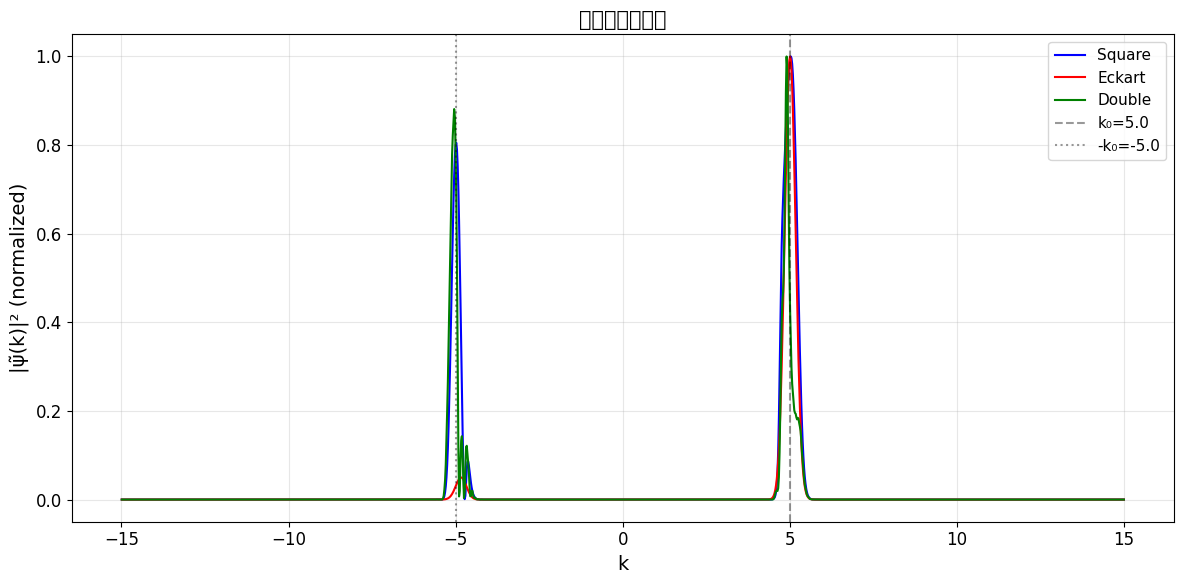

In [8]:
k_sorted = p_common.k_sorted
k_range = (-15, 15)
k_mask = (k_sorted >= k_range[0]) & (k_sorted <= k_range[1])
k_plot = k_sorted[k_mask]

fig, ax = plt.subplots(figsize=(12, 6))
for name, res, color in zip(
    ['Square', 'Eckart', 'Double'],
    results_list,
    ['blue', 'red', 'green']
):
    spec = res.momentum_spectra[-1][k_mask]
    spec_norm = spec / spec.max() if spec.max() > 0 else spec
    ax.plot(k_plot, spec_norm, color=color, linewidth=1.5, label=name)

ax.axvline(p_common.k0, color='k', linestyle='--', alpha=0.4, label=f'k₀={p_common.k0}')
ax.axvline(-p_common.k0, color='k', linestyle=':', alpha=0.4, label=f'-k₀={-p_common.k0}')
ax.set_xlabel('k')
ax.set_ylabel('|ψ̃(k)|² (normalized)')
ax.set_title('最终动量谱对比')
ax.legend()
plt.tight_layout()
plt.show()

## 7. 结论

| 势垒类型 | 特征 | 物理现象 |
|----------|------|----------|
| **方势垒** | 不连续势，最简模型 | 指数隧穿衰减，$T \sim e^{-2\kappa L}$ |
| **Eckart势** | 光滑势，有解析解 | 隧穿+量子反射，数值方法可精确验证 |
| **双势垒** | 量子阱+共振态 | 共振隧穿，透射率在共振能量处达到峰值 |

**数值方法验证**：
- Split-operator FFT 方法在 Eckart 势上与解析解吻合良好
- 概率守恒误差 < $10^{-4}$（CAP 吸收前）
- 时间步长 $\Delta t = 0.005$ 下，能量守恒良好

## 7. 结论

| 势垒类型 | 特征 | 物理现象 |
|----------|------|----------|
| **方势垒** | 不连续势，最简模型 | 指数隧穿衰减，$T \sim e^{-2\kappa L}$ |
| **Eckart势** | 光滑势，有解析解 | 隧穿+量子反射，数值方法可精确验证 |
| **双势垒** | 量子阱+共振态 | 共振隧穿，透射率在共振能量处达到峰值 |

**数值方法验证**：
- Split-operator FFT 方法在 Eckart 势上与解析解吻合良好
- 概率守恒误差 < $10^{-4}$（CAP 吸收前）
- 时间步长 $\Delta t = 0.005$ 下，能量守恒良好